# Topic: Summarising Data using Pandas

## Grocery Data Example

In [1]:
import pandas as pd
groceries = pd.read_csv('Data/groceries.csv', parse_dates=['ShoppingDate'], dayfirst=True) 
groceries

,ShoppingDate,Category,GroceryItem,CostPerItem,Quantity
0,2022-04-23,Baking,Rich Chocolate Cake Cake Mix,7.35,1
1,2022-04-23,Baking,Wild Blue Berry Muffins Cake Mix,3.56,5
2,2022-04-23,Baking,Desiccated Coconut,9.72,1
3,2022-04-23,Baking,White Paper Muffin Cases,0.76,1
4,2022-04-23,Baking,Dry Yeast,6.69,1
...,...,...,...,...,...
985,2022-09-03,Treats,Caramel/cookie slice,4.98,1
986,2022-09-03,Vegetables,Cabbage,4.00,1
987,2022-09-03,Vegetables,Red Capsicum,2.90,1
988,2022-09-03,Vegetables,Butternut Pumpkin,5.12,1


<style>
    .jp-RenderedMarkdown {
  background-color: yellow;
}
</style>  

<div style="background-color:palegreen">
<h3>How to compute a new Pandas DataFrame column</h3>
    
Example:

```bash
    mydataframe['newColumn'] = mydataframe.Column1 - mydataframe.Column2 / mydataframe.Column3
```
</div>

In [2]:
# Compute a new TotalCost column for each row (CostPerItem x Quantity)

groceries['TotalCost'] = groceries.CostPerItem * groceries.Quantity
groceries

,ShoppingDate,Category,GroceryItem,CostPerItem,Quantity,TotalCost
0,2022-04-23,Baking,Rich Chocolate Cake Cake Mix,7.35,1,7.35
1,2022-04-23,Baking,Wild Blue Berry Muffins Cake Mix,3.56,5,17.80
2,2022-04-23,Baking,Desiccated Coconut,9.72,1,9.72
3,2022-04-23,Baking,White Paper Muffin Cases,0.76,1,0.76
4,2022-04-23,Baking,Dry Yeast,6.69,1,6.69
...,...,...,...,...,...,...
985,2022-09-03,Treats,Caramel/cookie slice,4.98,1,4.98
986,2022-09-03,Vegetables,Cabbage,4.00,1,4.00
987,2022-09-03,Vegetables,Red Capsicum,2.90,1,2.90
988,2022-09-03,Vegetables,Butternut Pumpkin,5.12,1,5.12


<div style="background-color:palegreen">

### How to compute a new Pandas column using a Python function

Example:
```bash    
    def my_function(row) :
        if row.a == 7 :
            return row.c + row.d
        else
            return 42
            
    mydataframe['newCol'] = mydataframe.apply(my_function, axis=1)
```
</div>

In [3]:
# Change the TotalCost calculation so that a 10% discount is applied to an item if the quantity purchased is more than 5.
    
def discount(row):
    if row.Quantity > 5:
        return row.TotalCost * 0.9
    else:
        return row.TotalCost

groceries['TotalCost'] = groceries.apply(discount, axis=1)
groceries

,ShoppingDate,Category,GroceryItem,CostPerItem,Quantity,TotalCost
0,2022-04-23,Baking,Rich Chocolate Cake Cake Mix,7.35,1,7.35
1,2022-04-23,Baking,Wild Blue Berry Muffins Cake Mix,3.56,5,17.80
2,2022-04-23,Baking,Desiccated Coconut,9.72,1,9.72
3,2022-04-23,Baking,White Paper Muffin Cases,0.76,1,0.76
4,2022-04-23,Baking,Dry Yeast,6.69,1,6.69
...,...,...,...,...,...,...
985,2022-09-03,Treats,Caramel/cookie slice,4.98,1,4.98
986,2022-09-03,Vegetables,Cabbage,4.00,1,4.00
987,2022-09-03,Vegetables,Red Capsicum,2.90,1,2.90
988,2022-09-03,Vegetables,Butternut Pumpkin,5.12,1,5.12


In [4]:
# What is the total cost of all groceries purchased?

groceries.TotalCost.sum()

# Answer should be $7620.38

np.float64(7620.38)

<div style="background-color:palegreen">

### How to use a group by query in Pandas

Examples:
```bash      
    mydataframe.groupby('my_column').other_column.mean()
    mydataframe.groupby('my_column').other_column.sum()
    mydataframe.groupby('my_column').other_column.min()
``` 
</div>

In [5]:
# Use a group by to compute the total groceries purchased on each Shopping Date

daily_quantities = groceries.groupby('ShoppingDate').Quantity.sum()
daily_quantities

ShoppingDate
2022-04-23    67
2022-04-30    80
2022-05-07    66
2022-05-14    79
2022-05-21    92
2022-05-28    89
2022-06-04    78
2022-06-11    89
2022-06-18    62
2022-06-25    75
2022-07-02    60
2022-07-09    78
2022-07-16    75
2022-07-23    55
2022-07-30    97
2022-08-06    59
2022-08-13    79
2022-08-20    75
2022-08-27    70
2022-09-03    64
Name: Quantity, dtype: int64

<div style="background-color:palegreen">

### How to Visualize a Pandas DataFrame as a line plot

Example:
```bash     
    ax = mydataframe.plot(x, y, figsize=(width, height)) # width and height specified in inches
    ax.set_title('My Title')
    ax.set_xlabel('My X axis label')
    ax.set_ylabel('My Y axis label')
```
</div>

<Axes: xlabel='ShoppingDate', ylabel='Quantity'>

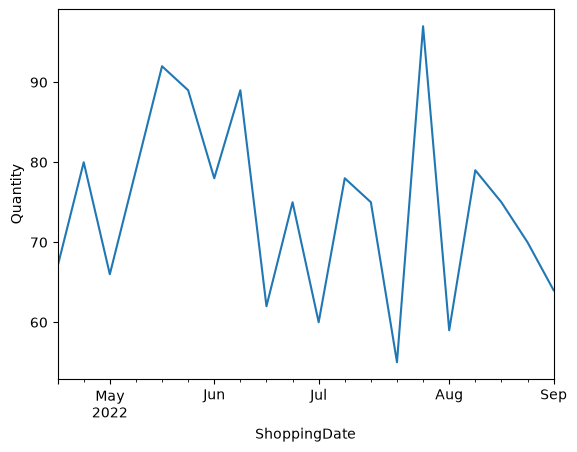

In [6]:
# Plot this data as a line graph with an appropriate title and axis labels

daily_quantities.plot(ylabel='Quantity')

<div style="background-color:palegreen">

### How to Visualize a Pandas DataFrame as a bar plot

Example:
```bash     
    ax = mydataframe.plot(x, y, kind = bar, figsize=(width, height)) # width and height specified in inches
```
</div>

<Axes: xlabel='ShoppingDate', ylabel='Quantity'>

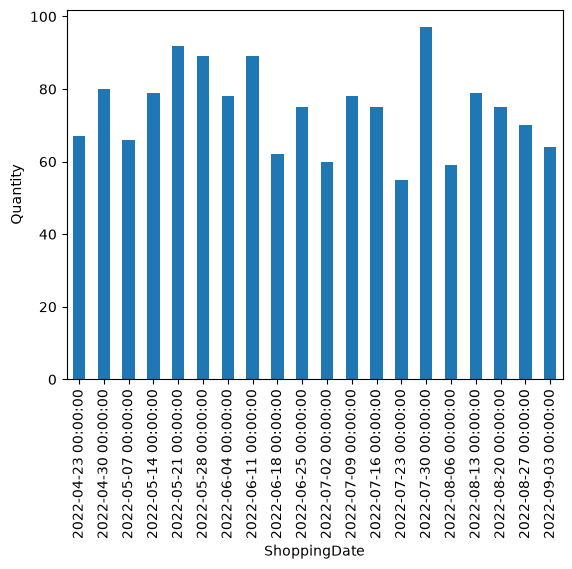

In [7]:
# Now visualize it using a bar graph instead

daily_quantities.plot(kind='bar', ylabel='Quantity')

In [8]:
# Use a group by to compute the total groceries purchased for each Category

total_by_category = groceries.groupby('Category').Quantity.sum()
total_by_category

Category
Bakery           40
Baking          146
Bathroom        106
Cereal            8
Cleaning         59
Dogs             24
Freezer         109
Fridge           91
Fruit            46
Herbs/Spices     94
Meat             51
Medical          39
Pantry          307
Pasta/Rice       50
Sauces           53
Treats          105
Vegetables      161
Name: Quantity, dtype: int64

<Axes: xlabel='Category', ylabel='Quantity'>

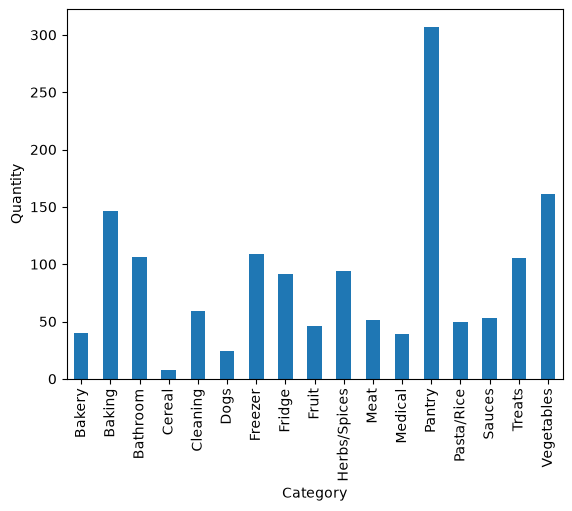

In [9]:
# Visualize category data using a bar graph

total_by_category.plot(kind='bar', ylabel='Quantity')

<div style="background-color:palegreen">

### How to Visualize a Pandas DataFrame as a pie plot

Example:
```bash     
    ax = mydataframe.plot.pie(y, figsize=(width, height), autopct='%.1f%%') # width and height specified in inches
```
</div>

<Axes: >

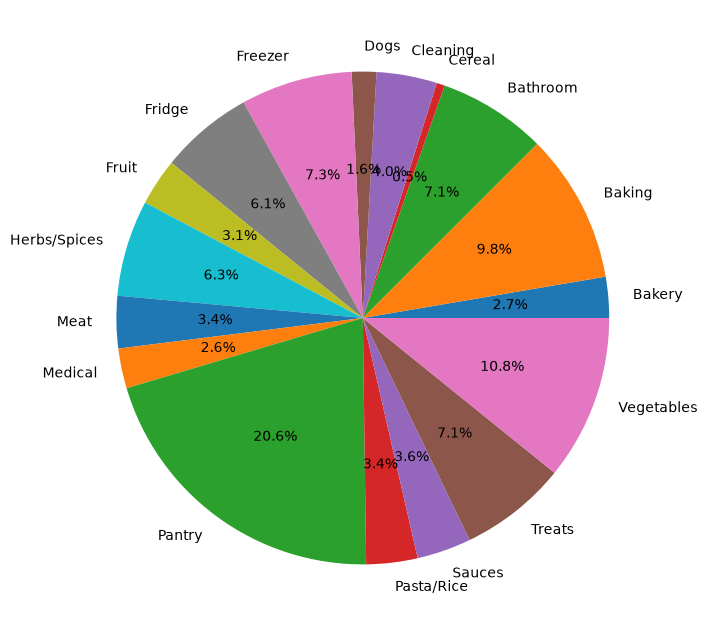

In [10]:
# Visualize the category data using a pie chart with percentages shown for each slice. 

total_by_category.plot(kind='pie', figsize=(8, 8), autopct='%.1f%%')

<div style="background-color:palegreen">

### How to use a group by with more than one column in Pandas

Examples:
```bash      
    mydataframe.groupby(['column1', 'column2']).other_column.mean()
    mydataframe.groupby(['column1', 'column2']).other_column.sum()
    mydataframe.groupby(['column1', 'column2']).other_column.min()
``` 
</div>

In [11]:
# Group by both the ShoppingDate and the Category and compute the total cost for each group

cost_summary = groceries.groupby(['ShoppingDate', 'Category']).TotalCost.sum()
cost_summary 

ShoppingDate  Category  
2022-04-23    Bakery         14.010
              Baking         49.440
              Bathroom       22.940
              Dogs            4.400
              Freezer         5.970
                             ...   
2022-09-03    Pantry        114.167
              Pasta/Rice      3.240
              Sauces         32.660
              Treats         63.191
              Vegetables     17.000
Name: TotalCost, Length: 295, dtype: float64

In [12]:
# What happens if you apply the unstack() method to these results?

cost_summary = cost_summary.unstack()
cost_summary

Category,Bakery,Baking,Bathroom,Cereal,Cleaning,Dogs,Freezer,Fridge,Fruit,Herbs/Spices,Meat,Medical,Pantry,Pasta/Rice,Sauces,Treats,Vegetables
ShoppingDate,,,,,,,,,,,,,,,,,
2022-04-23,14.010,49.440,22.940,NaN,NaN,4.400,5.970,8.320,10.780,24.010,NaN,7.800,84.323,9.960,12.112,11.710,6.820
2022-04-30,17.670,10.660,NaN,NaN,19.090,1.780,17.620,26.460,NaN,32.846,20.760,9.640,59.666,7.430,53.378,66.290,57.590
2022-05-07,16.340,40.270,4.910,NaN,0.760,7.600,41.860,8.230,6.920,58.630,29.510,4.110,40.170,9.870,NaN,21.710,2.738
2022-05-14,10.460,6.790,47.940,NaN,12.500,3.980,76.370,11.940,15.360,31.500,20.560,NaN,199.959,3.860,8.740,5.730,17.660
2022-05-21,4.410,58.508,31.440,NaN,NaN,NaN,12.840,25.810,NaN,53.526,NaN,78.207,96.424,NaN,13.710,17.560,29.540
2022-05-28,NaN,29.110,38.020,5.48,52.548,6.350,36.798,26.090,26.420,29.040,5.170,NaN,72.370,16.190,14.190,62.330,29.740
2022-06-04,2.450,33.530,12.370,NaN,41.128,1.430,5.620,17.520,8.970,9.640,10.500,NaN,203.023,NaN,0.810,21.510,33.900
2022-06-11,27.510,129.484,35.986,NaN,15.100,1.780,9.100,39.020,2.140,8.670,4.940,NaN,46.510,8.130,5.510,16.800,65.543
2022-06-18,NaN,18.490,62.047,6.07,4.200,36.666,20.230,3.870,2.040,24.070,18.640,NaN,45.890,7.430,4.300,14.460,80.712


<Axes: xlabel='ShoppingDate'>

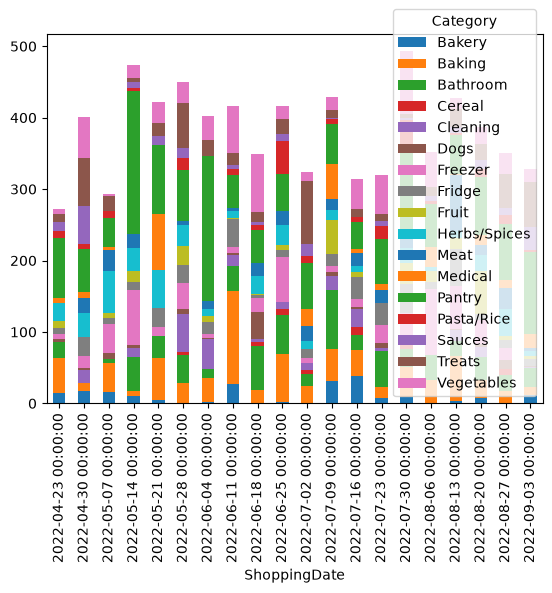

In [13]:
# Plot the resulting unstacked data as a stacked bar graph (set parameter stacked=True)

cost_summary.plot(kind='bar', stacked=True)

## Weather Data Example

In [14]:
weather = pd.read_csv('Data/BrisbaneDailyWeather.csv', index_col=0, parse_dates=[0])
weather

,MinTemp,MaxTemp,Rainfall
Date,,,
2022-02-13,18.6,29.3,7.2
2022-02-12,20.4,28.9,0.0
2022-02-11,19.1,31.3,0.0
2022-02-10,19.4,31.2,0.0
2022-02-09,18.6,30.0,0.0
...,...,...,...
1999-12-15,17.0,27.0,0.0
1999-12-14,17.0,26.0,0.2
1999-12-13,19.0,24.0,0.8


<Axes: xlabel='Date'>

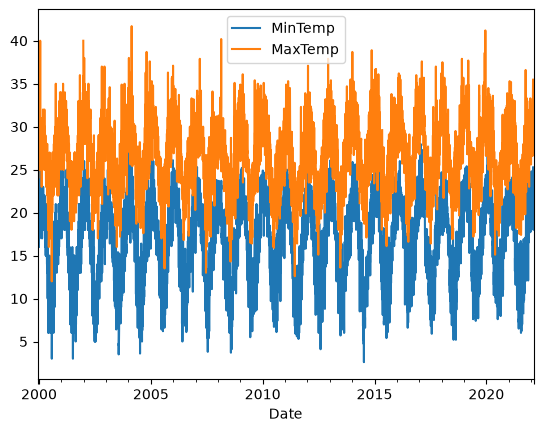

In [15]:
# Plot the MinTemp and MaxTemp columns together on a simple line plot

weather.plot(y=['MinTemp', 'MaxTemp'])

<div style="background-color:palegreen">

### How to access the parts of a DataFrame index of type date/time

Examples:
```bash      
    mydataframe.index.minute
    mydataframe.index.hour
    mydataframe.index.day
    mydataframe.index.day_name()
    mydataframe.index.day_of_week
    mydataframe.index.day_of_year    
    mydataframe.index.weekofyear 
    mydataframe.index.month
    mydataframe.index.month_name
    mydataframe.index.year  
``` 
</div>

In [16]:
# Use a group by to find the average Minimum and Maximum Temp for each day of the year

weather['Day'] = weather.index.day_of_year
day_averages = weather.groupby('Day')[['MinTemp', 'MaxTemp']].mean()
day_averages
# Result should be 366 rows × 2 columns

,MinTemp,MaxTemp
Day,,
1,21.030435,29.834783
2,21.204348,30.486957
3,21.552174,29.734783
4,21.113043,29.665217
5,21.608696,30.150000
...,...,...
362,20.365217,28.630435
363,20.373913,29.678261
364,20.478261,30.086957


<Axes: xlabel='Day'>

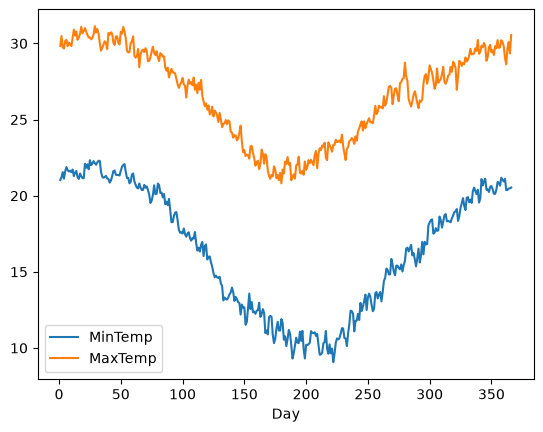

In [17]:
# Plot these day averages together on a single line plot

day_averages.plot()

In [18]:
# Compute the statistical correlation between all variables in the weather data
# Which columns are closely correlated?

weather.corr()
# MinTemp and MaxTemp have the highest correlation (0.74) All other correlations are weak.

,MinTemp,MaxTemp,Rainfall,Day
MinTemp,1.000000,0.743777,0.152545,-0.226125
MaxTemp,0.743777,1.000000,-0.014784,-0.154466
Rainfall,0.152545,-0.014784,1.000000,-0.044603
Day,-0.226125,-0.154466,-0.044603,1.000000


<div style="background-color:palegreen">

### How to Visualize a Pandas DataFrame as a scatter plot

Example:
```bash     
    ax = mydataframe.plot.scatter(x='column1', y='column2')
```
</div>

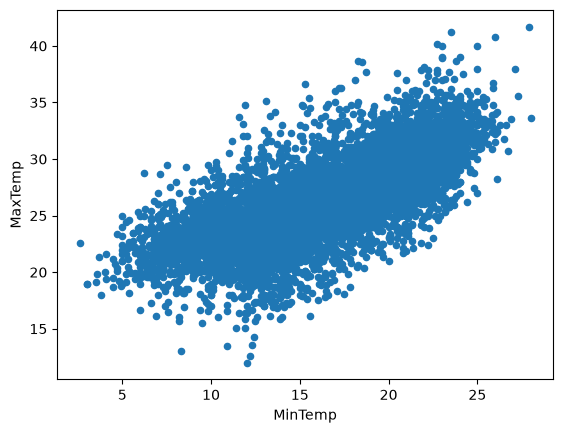

In [19]:
# Create a scatter plot of the minimum temperature vs the maximum temperate
# What pattern do you notice?

ax = weather.plot(x='MinTemp', y='MaxTemp', kind='scatter')
# we observe a moderate positive linear relationship, aligning with the correlation of 0.74 computed earlier.

In [20]:
# Determine the minimum and maximum values of the MaxTemp column

maxtemp_summary = weather.MaxTemp.agg(['min', 'max'])
maxtemp_summary

min    12.0
max    41.7
Name: MaxTemp, dtype: float64

In [32]:
# Compute a new column named month that contains the month number of the index
weather['month'] = weather.index.month

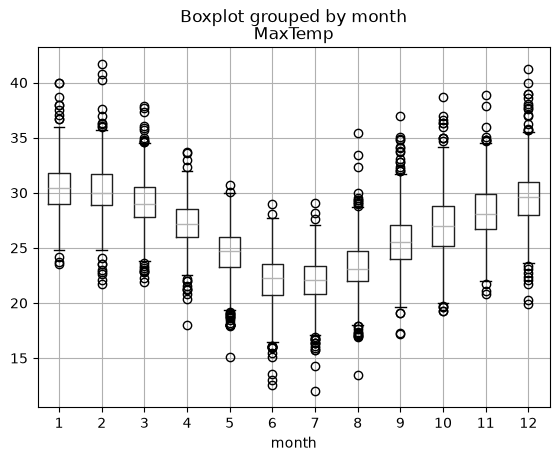

In [34]:
# Create  a box plot of the MaxTemp versus the month column

ax = weather.boxplot(column='MaxTemp', by='month')